# 04 — Cross-Validation & Equivalence (accuracy, MCC, AUC)  [R2-6]
Repeated 5x10-fold CV with Nadeau-Bengio-corrected paired TOST (±0.01). Runs a few minutes.

In [1]:
import json, inspect, warnings, os, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (StandardScaler, RobustScaler, PowerTransformer, MinMaxScaler, QuantileTransformer)
from sklearn.metrics import (accuracy_score, matthews_corrcoef, roc_auc_score, recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from scipy import stats
from lightgbm import LGBMClassifier
os.makedirs("results", exist_ok=True)
RS = 42
TEAL,ROSE,ORANGE,SAND,RED,LAV,SLATE,INK = ('#4A90A4','#C4887D','#E67E22','#C4A882','#C0392B','#8E7CC3','#7A8B9A','#2C3E4F')
plt.rcParams.update({'font.family':'DejaVu Sans','axes.facecolor':'#FAFBFC','figure.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.color':'#E4E9F0',
    'axes.titleweight':'bold','axes.axisbelow':True,'savefig.dpi':200,'savefig.bbox':'tight'})
NAMES = ['Manual Expert','DeepSeek','Claude Sonnet 4.6','GPT-5.4','CAAFE']
SHORT = ['Manual','DeepSeek','Claude 4.6','GPT-5.4','CAAFE']
COLS  = [TEAL,ROSE,RED,ORANGE,LAV]
CONT  = ['AGE','ANNUALCONTRIBUTION','ANNUALCLAIMAMOUNT','UNITSTOTAL']
DATA  = "Final Prepared Dataset - Diabetes and Hypertension Data.xlsx"

def load_raw():
    df = pd.read_excel(DATA)
    n_raw = len(df); df = df.drop_duplicates().reset_index(drop=True); n_dup = n_raw - len(df)
    df["ADHERENCE"] = (df["ADHERENCE"]=="ADHERENT").astype(int)
    for c in df.columns:
        if df[c].dtype=="bool": df[c]=df[c].astype(int)
    return df, n_raw, n_dup

def load_and_split():
    df,_,_ = load_raw()
    y=df["ADHERENCE"]; X=df.drop(columns=["ADHERENCE"])
    return train_test_split(X,y,test_size=0.2,stratify=y,random_state=RS)

def _manual(Xp):
    Xp=Xp.copy()
    Xp["LOG_CLAIM"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]); Xp["LOG_UNITS"]=np.log1p(Xp["UNITSTOTAL"])
    Xp["LOG_CONTRIB"]=np.log1p(Xp["ANNUALCONTRIBUTION"])
    Xp["CLAIM_PER_UNIT"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]/(Xp["UNITSTOTAL"]+1))
    Xp["CLAIM_RATIO"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]/(Xp["ANNUALCONTRIBUTION"]+1))
    Xp["UNITS_PER_AGE"]=Xp["UNITSTOTAL"]/(Xp["AGE"]+1); return Xp

_NS={"np":np,"pd":pd,"StandardScaler":StandardScaler,"RobustScaler":RobustScaler,
     "PowerTransformer":PowerTransformer,"MinMaxScaler":MinMaxScaler,"QuantileTransformer":QuantileTransformer}
def _load(p):
    ns=dict(_NS); exec(open(p,encoding="utf-8").read(),ns); return ns["preprocess"]
FROZEN={"DeepSeek":_load("llm_raw/DeepSeek_preprocess.py"),
        "Claude Sonnet 4.6":_load("llm_raw/Claude_Sonnet_4.6_preprocess.py"),
        "GPT-5.4":_load("llm_raw/GPT-5.4_preprocess.py")}
def _caafe(frame):
    ns={"df":frame.copy(),"np":np,"pd":pd}; exec(open("llm_raw/CAAFE_code.py",encoding="utf-8").read(),ns)
    return ns["df"].select_dtypes(include=[np.number]).fillna(0)
def transform_pair(name,x_fit,x_eval):
    if name=="Manual Expert": return _manual(x_fit),_manual(x_eval)
    if name=="CAAFE":
        tr=_caafe(x_fit); te=_caafe(x_eval).reindex(columns=tr.columns,fill_value=0); return tr,te
    tr,te=FROZEN[name](x_fit.copy(),x_eval.copy())
    if not isinstance(tr,pd.DataFrame):
        cols=(list(x_fit.columns)+["CONTRIBUTION_CLAIM_RATIO","UNITS_PER_CLAIM"]) if (name=="DeepSeek" and tr.shape[1]==x_fit.shape[1]+2) else [f"f{i}" for i in range(tr.shape[1])]
        tr=pd.DataFrame(tr,index=x_fit.index,columns=cols)
    if not isinstance(te,pd.DataFrame): te=pd.DataFrame(te,index=x_eval.index,columns=tr.columns)
    return tr,te.reindex(columns=tr.columns,fill_value=0)
def san(df): return pd.DataFrame(df).replace([np.inf,-np.inf],np.nan).fillna(0.0)
def nb_se(d,k=10):
    d=np.asarray(d); n=d.size; return np.sqrt(d.var(ddof=1)*(1.0/n+(1.0/k)/(1-1.0/k)))
def tost90(d,k=10):
    d=np.asarray(d); m=d.mean(); se=nb_se(d,k); c=stats.t.ppf(0.95,d.size-1); return m,se,[m-c*se,m+c*se]
def cv_metrics(name,X,y,drop_units=False,k=10,repeats=1):
    accs,mccs,aucs=[],[],[]
    for r in range(repeats):
        for tr,va in StratifiedKFold(k,shuffle=True,random_state=(RS if repeats==1 else 2026+r)).split(X,y):
            ftr,fva=transform_pair(name,X.iloc[tr],X.iloc[va])
            if drop_units:
                uc=[c for c in ftr.columns if 'UNIT' in c.upper()]
                ftr=ftr.drop(columns=uc); fva=fva.drop(columns=[c for c in uc if c in fva.columns])
            ftr,fva=san(ftr),san(fva)
            m=LGBMClassifier(random_state=RS,verbose=-1,n_jobs=1).fit(ftr,y.iloc[tr])
            p=m.predict(fva); pr=m.predict_proba(fva)[:,1]
            accs.append(accuracy_score(y.iloc[va],p)); mccs.append(matthews_corrcoef(y.iloc[va],p)); aucs.append(roc_auc_score(y.iloc[va],pr))
    return np.array(accs),np.array(mccs),np.array(aucs)
x_tr,x_ho,y_tr,y_ho = load_and_split()
print("Setup complete |", f"{len(x_tr)+len(x_ho):,} records, {x_tr.shape[1]} predictors")

Setup complete | 24,071 records, 11 predictors


In [2]:
fold={n:cv_metrics(n,x_tr,y_tr,repeats=5) for n in NAMES}
core=pd.DataFrame([[n,round(fold[n][0].mean(),4),round(fold[n][1].mean(),3),round(fold[n][2].mean(),3)] for n in NAMES],
                  columns=['Pipeline','CV accuracy','CV MCC','CV AUC'])
acc=[fold[n][0].mean() for n in NAMES]; print('Accuracy span: %.4f'%(max(acc)-min(acc))); display(core)
tost=[]
for mi,ml in [(0,'ACC'),(1,'MCC'),(2,'AUC')]:
    for n in NAMES[1:]:
        m,se,ci=tost90(fold['Manual Expert'][mi]-fold[n][mi])
        tost.append([ml,n,round(m,4),round(se,4),f"[{ci[0]:+.4f}, {ci[1]:+.4f}]",abs(ci[0])<0.01 and abs(ci[1])<0.01])
tost=pd.DataFrame(tost,columns=['Metric','vs Manual','Mean diff','Corrected SE','90% CI','Within ±0.01']); display(tost)
with pd.ExcelWriter('results/04_equivalence.xlsx') as w: core.to_excel(w,'cv_means',index=False); tost.to_excel(w,'tost',index=False)

Accuracy span: 0.0026


,Pipeline,CV accuracy,CV MCC,CV AUC
0,Manual Expert,0.8213,0.642,0.903
1,DeepSeek,0.8229,0.645,0.903
2,Claude Sonnet 4.6,0.8214,0.641,0.902
3,GPT-5.4,0.8215,0.641,0.902
4,CAAFE,0.8204,0.640,0.902


,Metric,vs Manual,Mean diff,Corrected SE,90% CI,Within ±0.01
0,ACC,DeepSeek,-0.0016,0.0015,"[-0.0041, +0.0009]",True
1,ACC,Claude Sonnet 4.6,-0.0001,0.0016,"[-0.0027, +0.0025]",True
2,ACC,GPT-5.4,-0.0002,0.0015,"[-0.0026, +0.0023]",True
3,ACC,CAAFE,0.0010,0.0017,"[-0.0019, +0.0038]",True
4,MCC,DeepSeek,-0.0031,0.0030,"[-0.0083, +0.0020]",True
5,MCC,Claude Sonnet 4.6,0.0008,0.0033,"[-0.0047, +0.0064]",True
6,MCC,GPT-5.4,0.0004,0.0031,"[-0.0048, +0.0055]",True
7,MCC,CAAFE,0.0018,0.0035,"[-0.0041, +0.0077]",True
8,AUC,DeepSeek,-0.0004,0.0006,"[-0.0014, +0.0006]",True
9,AUC,Claude Sonnet 4.6,0.0010,0.0008,"[-0.0004, +0.0023]",True


### CV accuracy distribution (box plot)

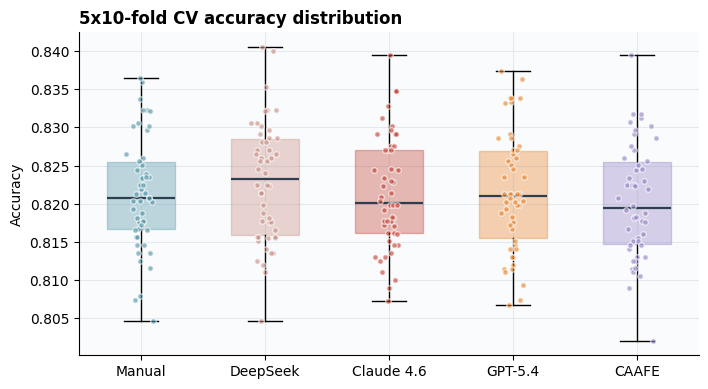

In [3]:
data=[fold[n][0] for n in NAMES]
fig,ax=plt.subplots(figsize=(8,4.2)); bp=ax.boxplot(data,widths=0.55,patch_artist=True,
    medianprops=dict(color=INK,linewidth=1.6),flierprops=dict(marker='o',markersize=4,markerfacecolor='none',markeredgecolor=SLATE))
for patch,c in zip(bp['boxes'],COLS): patch.set_facecolor(c); patch.set_alpha(.35); patch.set_edgecolor(c)
rng=np.random.default_rng(0)
for i,n in enumerate(NAMES):
    yv=fold[n][0]; ax.scatter(rng.normal(i+1,.05,len(yv)),yv,s=16,color=COLS[i],alpha=.6,edgecolor='white',zorder=4)
ax.set_xticks(range(1,6)); ax.set_xticklabels(SHORT); ax.set_ylabel('Accuracy')
ax.set_title('5x10-fold CV accuracy distribution',loc='left')
plt.savefig('results/04_cv_boxplot.png'); plt.show()